In [18]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [19]:
# Load the kidney waitlist dataset

import pandas as pd

url = "https://raw.githubusercontent.com/Break-Through-Tech/Healthcare-1A-predicting-organ-transplant-waitlist-outcomes-and-optimizing-allocation/main/data/kidney_waitlist_analytic.csv.gz"

df = pd.read_csv(url, compression="gzip")

df.head()

,ON_DIALYSIS,A2A2B_ELIGIBILITY,GENDER,ABO,BMI_TCR,FUNC_STAT_TCR,INIT_STAT,INIT_CPRA,END_CPRA,REM_CD,...,PSTATUS,PTIME,TRR_ID_CODE,DONOR_ID,LISTING_CTR_CODE,outcome,event_adverse,event_transplant,censored,days_to_event
0,Y,NaN,F,B,31.63,2080.0,4099,0.0,0.0,8.0,...,NaN,NaN,NaN,NaN,13609,died,1,0,0,287.0
1,Y,NaN,M,A,30.04,2070.0,4099,0.0,NaN,24.0,...,NaN,NaN,NaN,NaN,6975,removed_administrative,0,0,0,2322.0
2,N,NaN,F,O,32.85,2070.0,4099,0.0,0.0,8.0,...,NaN,NaN,NaN,NaN,19716,died,1,0,0,604.0
3,Y,NaN,M,A,20.00,2090.0,4099,0.0,0.0,13.0,...,NaN,NaN,NaN,NaN,8587,removed_too_sick,1,0,0,909.0
4,Y,NaN,M,AB,23.30,2070.0,4010,0.0,0.0,13.0,...,NaN,NaN,NaN,NaN,18352,removed_too_sick,1,0,0,231.0


In [20]:
# Check the size of the dataset
df.shape

(494862, 38)

In [21]:
# Analysize the data
df.describe()

,A2A2B_ELIGIBILITY,BMI_TCR,FUNC_STAT_TCR,INIT_STAT,INIT_CPRA,END_CPRA,REM_CD,DAYSWAIT_CHRON,END_STAT,INIT_AGE,...,WL_ID_CODE,DIAG_KI,PSTATUS,PTIME,DONOR_ID,LISTING_CTR_CODE,event_adverse,event_transplant,censored,days_to_event
count,38258.000000,493304.000000,490887.000000,494862.000000,352121.000000,352414.000000,391562.000000,494809.000000,494862.000000,494862.000000,...,4.948620e+05,229322.000000,230755.000000,227512.000000,230755.000000,494862.000000,494862.000000,494862.000000,494862.000000,494803.000000
mean,0.282242,64.700077,2106.332755,4036.217733,9.786130,29.219320,9.150027,649.532775,4038.288725,51.874533,...,1.595489e+06,2890.667337,0.119083,1241.054252,629284.062920,13040.187040,0.140934,0.473726,0.208745,649.541492
std,0.450096,3141.118209,343.735143,40.559675,24.799939,36.408157,5.932887,654.238307,41.437826,14.601018,...,2.306050e+05,534.282179,0.323887,947.761267,79431.124919,7742.892814,0.347954,0.499310,0.406412,654.237636
min,0.000000,0.180000,1.000000,4010.000000,0.000000,0.000000,4.000000,0.000000,4010.000000,0.000000,...,1.835720e+05,999.000000,0.000000,0.000000,415814.000000,124.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,24.650000,2070.000000,4010.000000,0.000000,0.000000,4.000000,144.000000,4010.000000,43.000000,...,1.397019e+06,3008.000000,0.000000,379.000000,565175.500000,6293.000000,0.000000,0.000000,0.000000,144.000000
50%,0.000000,28.530000,2080.000000,4010.000000,0.000000,6.860000,8.000000,433.000000,4010.000000,54.000000,...,1.597336e+06,3040.000000,0.000000,1087.000000,630483.000000,13454.000000,0.000000,0.000000,0.000000,433.000000
75%,1.000000,32.850000,2090.000000,4099.000000,0.000000,56.930000,14.000000,965.000000,4099.000000,63.000000,...,1.795160e+06,3070.000000,0.000000,1840.000000,696537.500000,19964.000000,0.000000,1.000000,0.000000,965.000000
max,1.000000,430226.670000,4100.000000,4099.000000,100.000000,100.000000,45.000000,4200.000000,4099.000000,91.000000,...,1.993444e+06,3074.000000,1.000000,4131.000000,767775.000000,27149.000000,1.000000,1.000000,1.000000,4200.000000


In [22]:
# see the types of each columns
print(df.dtypes)

ON_DIALYSIS              object
A2A2B_ELIGIBILITY       float64
GENDER                   object
ABO                      object
BMI_TCR                 float64
FUNC_STAT_TCR           float64
INIT_STAT                 int64
INIT_CPRA               float64
END_CPRA                float64
REM_CD                  float64
DAYSWAIT_CHRON          float64
END_STAT                  int64
INIT_AGE                  int64
DIALYSIS_DATE            object
END_DATE                 object
INIT_DATE                object
ETHCAT                    int64
PT_CODE                   int64
DAYSWAIT_ALLOC          float64
COMPOSITE_DEATH_DATE     object
REGION                    int64
WL_ID_CODE                int64
PREV_TX                  object
TX_DATE                  object
DON_TY                   object
DIAG_KI                 float64
MULTIORG                 object
ORGAN                    object
PSTATUS                 float64
PTIME                   float64
TRR_ID_CODE              object
DONOR_ID

In [23]:
# Check the number of missing values per column
print(df.isnull().sum())

ON_DIALYSIS                  0
A2A2B_ELIGIBILITY       456604
GENDER                       0
ABO                          0
BMI_TCR                   1558
FUNC_STAT_TCR             3975
INIT_STAT                    0
INIT_CPRA               142741
END_CPRA                142448
REM_CD                  103300
DAYSWAIT_CHRON              53
END_STAT                     0
INIT_AGE                     0
DIALYSIS_DATE           134245
END_DATE                     0
INIT_DATE                    0
ETHCAT                       0
PT_CODE                      0
DAYSWAIT_ALLOC            6745
COMPOSITE_DEATH_DATE    398512
REGION                       0
WL_ID_CODE                   0
PREV_TX                 264107
TX_DATE                 264107
DON_TY                  264107
DIAG_KI                 265540
MULTIORG                483004
ORGAN                   264107
PSTATUS                 264107
PTIME                   267350
TRR_ID_CODE             264107
DONOR_ID                264107
LISTING_

In [24]:
# View the number of unique values each object column has
print(df.select_dtypes(include='object').nunique())

ON_DIALYSIS                  2
GENDER                       2
ABO                          8
DIALYSIS_DATE             8953
END_DATE                  4196
INIT_DATE                 3805
COMPOSITE_DEATH_DATE      4101
PREV_TX                      2
TX_DATE                   4189
DON_TY                       3
MULTIORG                     1
ORGAN                        2
TRR_ID_CODE             230755
outcome                      7
dtype: int64


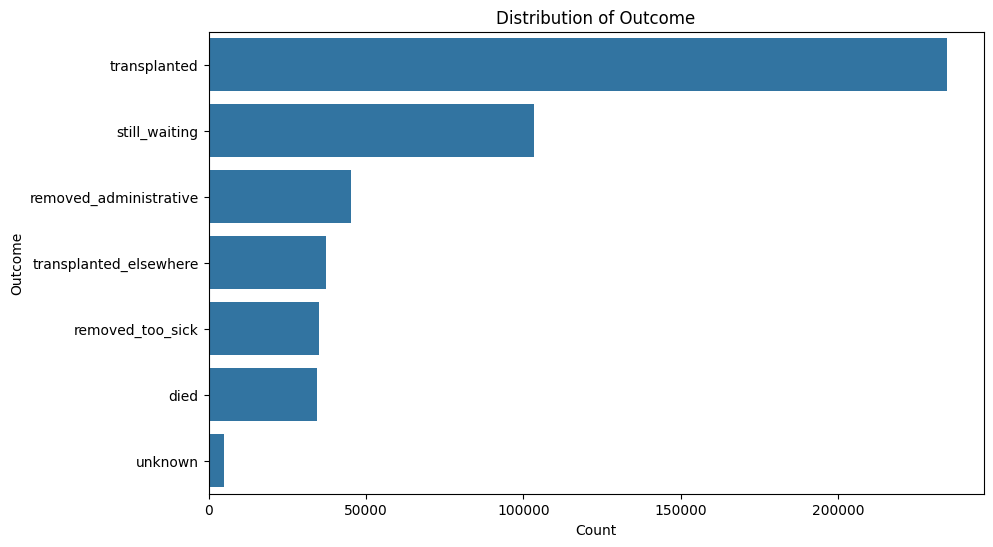

In [25]:
# Visualize the outcomes
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='outcome', order = df['outcome'].value_counts().index)
plt.title('Distribution of Outcome')
plt.xlabel('Count')
plt.ylabel('Outcome')
plt.show()

**Drop useless columns**

I will drop columns: A2A2B_ELIGIBILITY, COMPOSITE_DEATH_DATE, MULTIORG, DONOR_ID, TRR_ID_CODE

Reasons:
  - Too much missing values, more than 50%: A2A2B_ELIGIBILITY, COMPOSITE_DEATH_DATE, MULTIORG
  - These columns consist of patient ID, which are not really usefull for prediction: DONOR_ID, TRR_ID_CODE

Other columns we might need to consider, but not sure:
  - Event_adverse
  - Event_transplant
  - Censored
  - Days_to_event
  - DIALYSIS_DATE
  - END_DATE
  - INIT_DATE
  - TX_DATE

Reasons:
  - Too much missing values
  - Dates are not usually usefull for prediction

In [31]:
# Define the columns to drop
columns_to_drop = [
    'A2A2B_ELIGIBILITY',
    'COMPOSITE_DEATH_DATE',
    'MULTIORG',
    'DONOR_ID',
    'TRR_ID_CODE'
]

# Drop columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Display the change in dataset dimensions
print(f"Original shape: {df.shape}")
print(f"New shape after dropping columns: {df_cleaned.shape}")


Original shape: (494862, 38)
New shape after dropping columns: (494862, 33)


In [33]:
# Analysis of new data frame
print(df_cleaned.select_dtypes(include='object').nunique())

ON_DIALYSIS         2
GENDER              2
ABO                 8
DIALYSIS_DATE    8953
END_DATE         4196
INIT_DATE        3805
PREV_TX             2
TX_DATE          4189
DON_TY              3
ORGAN               2
outcome             7
dtype: int64


In [34]:
# Check the number of missing values per column
print(df_cleaned.isnull().sum())

ON_DIALYSIS              0
GENDER                   0
ABO                      0
BMI_TCR               1558
FUNC_STAT_TCR         3975
INIT_STAT                0
INIT_CPRA           142741
END_CPRA            142448
REM_CD              103300
DAYSWAIT_CHRON          53
END_STAT                 0
INIT_AGE                 0
DIALYSIS_DATE       134245
END_DATE                 0
INIT_DATE                0
ETHCAT                   0
PT_CODE                  0
DAYSWAIT_ALLOC        6745
REGION                   0
WL_ID_CODE               0
PREV_TX             264107
TX_DATE             264107
DON_TY              264107
DIAG_KI             265540
ORGAN               264107
PSTATUS             264107
PTIME               267350
LISTING_CTR_CODE         0
outcome                  0
event_adverse            0
event_transplant         0
censored                 0
days_to_event           59
dtype: int64


**Replacing missing values**

In [36]:
# Get a list of all columns with float64 or int64 data types
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Float64 and Int64 columns in df_cleaned:")
print(numeric_cols)

Float64 and Int64 columns in df_cleaned:
['BMI_TCR', 'FUNC_STAT_TCR', 'INIT_STAT', 'INIT_CPRA', 'END_CPRA', 'REM_CD', 'DAYSWAIT_CHRON', 'END_STAT', 'INIT_AGE', 'ETHCAT', 'PT_CODE', 'DAYSWAIT_ALLOC', 'REGION', 'WL_ID_CODE', 'DIAG_KI', 'PSTATUS', 'PTIME', 'LISTING_CTR_CODE', 'event_adverse', 'event_transplant', 'censored', 'days_to_event']


In [37]:
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

In [38]:
# Get a list of all columns with object data types
obj_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print("Object columns in df_cleaned:")
print(obj_cols)

Object columns in df_cleaned:
['ON_DIALYSIS', 'GENDER', 'ABO', 'DIALYSIS_DATE', 'END_DATE', 'INIT_DATE', 'PREV_TX', 'TX_DATE', 'DON_TY', 'ORGAN', 'outcome']


In [39]:
for col in obj_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

In [40]:
# Check the number of missing values per column
print(df_cleaned.isnull().sum())

ON_DIALYSIS         0
GENDER              0
ABO                 0
BMI_TCR             0
FUNC_STAT_TCR       0
INIT_STAT           0
INIT_CPRA           0
END_CPRA            0
REM_CD              0
DAYSWAIT_CHRON      0
END_STAT            0
INIT_AGE            0
DIALYSIS_DATE       0
END_DATE            0
INIT_DATE           0
ETHCAT              0
PT_CODE             0
DAYSWAIT_ALLOC      0
REGION              0
WL_ID_CODE          0
PREV_TX             0
TX_DATE             0
DON_TY              0
DIAG_KI             0
ORGAN               0
PSTATUS             0
PTIME               0
LISTING_CTR_CODE    0
outcome             0
event_adverse       0
event_transplant    0
censored            0
days_to_event       0
dtype: int64


**One hot encoding**

For one-hot encoding, I will select the top 10 most frequent values in each column.

In [42]:
# Get a list of all columns with object data types
obj_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()


In [43]:
# Identify object columns to encode (excluding the target variable 'outcome')
cols_to_encode = []

for col in obj_cols:
    if col != 'outcome':
        cols_to_encode.append(col)

# Create a copy of the dataframe to store encoded values
df_encoded = df_cleaned.copy()

for col in cols_to_encode:
    # Get the top 10 most frequent categories
    top_10 = df_cleaned[col].value_counts().index[:10]

    # For each of the top 10 categories, create a new binary column
    for category in top_10:
        new_col_name = f"{col}_{category}"
        df_encoded[new_col_name] = (df_cleaned[col] == category).astype(int)

    # Drop the original object column after encoding
    df_encoded = df_encoded.drop(columns=[col])

# Display the new columns and the updated shape
print(f"Original shape: {df_cleaned.shape}")
print(f"Encoded shape: {df_encoded.shape}")
display(df_encoded.head())

Original shape: (494862, 33)
Encoded shape: (494862, 82)


,BMI_TCR,FUNC_STAT_TCR,INIT_STAT,INIT_CPRA,END_CPRA,REM_CD,DAYSWAIT_CHRON,END_STAT,INIT_AGE,ETHCAT,...,TX_DATE_2025-07-09,TX_DATE_2025-12-16,TX_DATE_2021-04-14,TX_DATE_2025-11-12,TX_DATE_2023-11-28,DON_TY_C,DON_TY_L,DON_TY_F,ORGAN_KI,ORGAN_KP
0,31.63,2080.0,4099,0.0,0.00000,8.0,287.0,4099,53,2,...,0,0,0,0,0,1,0,0,1,0
1,30.04,2070.0,4099,0.0,29.21932,24.0,2322.0,4099,56,1,...,0,0,0,0,0,1,0,0,1,0
2,32.85,2070.0,4099,0.0,0.00000,8.0,604.0,4099,47,1,...,0,0,0,0,0,1,0,0,1,0
3,20.00,2090.0,4099,0.0,0.00000,13.0,909.0,4099,61,5,...,0,0,0,0,0,1,0,0,1,0
4,23.30,2070.0,4010,0.0,0.00000,13.0,231.0,4099,61,2,...,0,0,0,0,0,1,0,0,1,0


In [44]:
df_encoded.describe()

,BMI_TCR,FUNC_STAT_TCR,INIT_STAT,INIT_CPRA,END_CPRA,REM_CD,DAYSWAIT_CHRON,END_STAT,INIT_AGE,ETHCAT,...,TX_DATE_2025-07-09,TX_DATE_2025-12-16,TX_DATE_2021-04-14,TX_DATE_2025-11-12,TX_DATE_2023-11-28,DON_TY_C,DON_TY_L,DON_TY_F,ORGAN_KI,ORGAN_KP
count,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,...,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000,494862.000000
mean,64.700077,2106.332755,4036.217733,9.786130,29.219320,9.150027,649.532775,4038.288725,51.874533,5.907538,...,0.000249,0.000247,0.000247,0.000242,0.000242,0.871271,0.128727,0.000002,0.999976,0.000024
std,3136.169627,342.351823,40.559675,20.919647,30.724373,5.277450,654.203271,41.437826,14.601018,59.611413,...,0.015764,0.015699,0.015699,0.015570,0.015570,0.334900,0.334898,0.001422,0.004924,0.004924
min,0.180000,1.000000,4010.000000,0.000000,0.000000,4.000000,0.000000,4010.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.660000,2070.000000,4010.000000,0.000000,0.000000,4.000000,144.000000,4010.000000,43.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,28.560000,2080.000000,4010.000000,0.000000,29.219320,9.150027,434.000000,4010.000000,54.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,32.890000,2090.000000,4099.000000,9.786130,32.810000,13.000000,965.000000,4099.000000,63.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,430226.670000,4100.000000,4099.000000,100.000000,100.000000,45.000000,4200.000000,4099.000000,91.000000,998.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Z-score normalization**

Upon analyzing the data, I think the gap across some features are too large. For this reason, I will apply Z-score normalization to put the data into the same scale.

In [49]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (excluding binary/one-hot columns and targets)
# We'll use the original numeric_cols list we computed earlier
cols_to_scale = [col for col in numeric_cols if col in df_encoded.columns]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to our numeric columns in df_encoded
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

# Show statistics to verify the scale has a mean around 0 and std of 1
display(df_encoded[cols_to_scale].describe().round(4))

,BMI_TCR,FUNC_STAT_TCR,INIT_STAT,INIT_CPRA,END_CPRA,REM_CD,DAYSWAIT_CHRON,END_STAT,INIT_AGE,ETHCAT,...,REGION,WL_ID_CODE,DIAG_KI,PSTATUS,PTIME,LISTING_CTR_CODE,event_adverse,event_transplant,censored,days_to_event
count,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,...,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000,494862.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,...,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-0.0206,-6.1496,-0.6464,-0.4678,-0.9510,-0.9759,-0.9929,-0.6827,-3.5528,-0.0823,...,-1.5217,-6.1227,-5.2011,-0.5384,-1.9312,-1.6681,-0.4050,-0.9488,-0.5136,-0.9929
25%,-0.0128,-0.1061,-0.6464,-0.4678,-0.9510,-0.9759,-0.7727,-0.6827,-0.6078,-0.0823,...,-0.8818,-0.8607,-0.0000,-0.5384,-0.1868,-0.8714,-0.4050,-0.9488,-0.5136,-0.7728
50%,-0.0115,-0.0769,-0.6464,-0.4678,-0.0000,0.0000,-0.3295,-0.6827,0.1456,-0.0656,...,-0.2419,0.0080,-0.0000,-0.0000,-0.0000,0.0534,-0.4050,-0.9488,-0.5136,-0.3295
75%,-0.0101,-0.0477,1.5479,0.0000,0.1169,0.7295,0.4822,1.4651,0.7620,-0.0320,...,1.0378,0.8659,0.4106,-0.0000,-0.0000,0.8942,-0.4050,1.0540,-0.5136,0.4822
max,137.1617,5.8235,1.5479,4.3124,2.3037,6.7931,5.4272,1.4651,2.6796,16.6427,...,1.6776,1.7257,0.5041,3.9830,4.4971,1.8222,2.4689,1.0540,1.9469,5.4272
